In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn import linear_model

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Read the dataset
df = pd.read_csv('Student_Performance.csv')


In [3]:
# Display basic information about the dataset
print("--- Dataset Info ---")
print(df.info())


--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype
---  ------                            --------------  -----
 0   Hours Studied                     10000 non-null  int64
 1   Previous Scores                   10000 non-null  int64
 2   Extracurricular Activities        10000 non-null  str  
 3   Sleep Hours                       10000 non-null  int64
 4   Sample Question Papers Practiced  10000 non-null  int64
 5   Performance Index                 10000 non-null  int64
dtypes: int64(5), str(1)
memory usage: 468.9 KB
None


In [4]:
print("\n--- First 5 Rows ---")
print(df.head())


--- First 5 Rows ---
   Hours Studied  Previous Scores Extracurricular Activities  Sleep Hours  \
0              7               99                        Yes            9   
1              4               82                         No            4   
2              8               51                        Yes            7   
3              5               52                        Yes            5   
4              7               75                         No            8   

   Sample Question Papers Practiced  Performance Index  
0                                 1                 91  
1                                 2                 65  
2                                 2                 45  
3                                 2                 36  
4                                 5                 66  


In [5]:
print("\n--- Shape ---")
print(df.shape)


--- Shape ---
(10000, 6)


In [6]:
print("\n--- Missing Values ---")
print(df.isnull().sum())


--- Missing Values ---
Hours Studied                       0
Previous Scores                     0
Extracurricular Activities          0
Sleep Hours                         0
Sample Question Papers Practiced    0
Performance Index                   0
dtype: int64


In [7]:
print("\n--- Summary Statistics ---")
print(df.describe())


--- Summary Statistics ---
       Hours Studied  Previous Scores   Sleep Hours  \
count   10000.000000     10000.000000  10000.000000   
mean        4.992900        69.445700      6.530600   
std         2.589309        17.343152      1.695863   
min         1.000000        40.000000      4.000000   
25%         3.000000        54.000000      5.000000   
50%         5.000000        69.000000      7.000000   
75%         7.000000        85.000000      8.000000   
max         9.000000        99.000000      9.000000   

       Sample Question Papers Practiced  Performance Index  
count                      10000.000000       10000.000000  
mean                           4.583300          55.224800  
std                            2.867348          19.212558  
min                            0.000000          10.000000  
25%                            2.000000          40.000000  
50%                            5.000000          55.000000  
75%                            7.000000          

In [8]:
# Convert Categorical Variables to Numeric
df_converted = pd.get_dummies(
    df,
    columns=['Extracurricular Activities'],
    drop_first=True,
    dtype=int
)

print(df_converted.head())

   Hours Studied  Previous Scores  Sleep Hours  \
0              7               99            9   
1              4               82            4   
2              8               51            7   
3              5               52            5   
4              7               75            8   

   Sample Question Papers Practiced  Performance Index  \
0                                 1                 91   
1                                 2                 65   
2                                 2                 45   
3                                 2                 36   
4                                 5                 66   

   Extracurricular Activities_Yes  
0                               1  
1                               0  
2                               1  
3                               1  
4                               0  


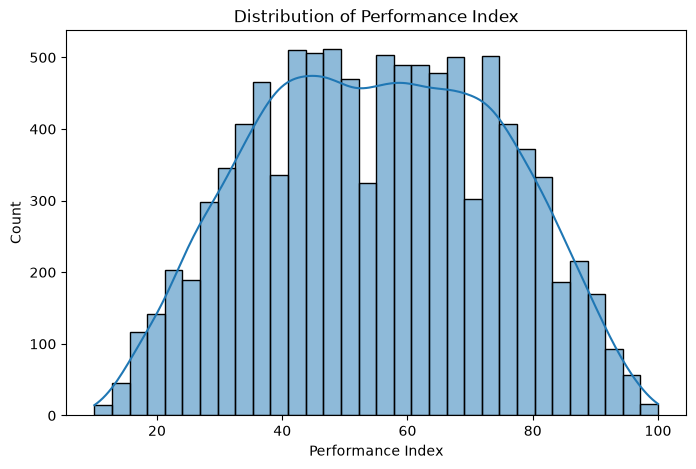

In [9]:
# Exploratory Data Analysis
plt.figure(figsize=(8,5)) 
sns.histplot(df['Performance Index'], kde=True) 
plt.title('Distribution of Performance Index') 
plt.show()

In [10]:
# Correlation Analysis 
print("\n--- Correlation with Performance Index ---")
print(df.corr(numeric_only=True)['Performance Index'].sort_values(ascending=False))


--- Correlation with Performance Index ---
Performance Index                   1.000000
Previous Scores                     0.915189
Hours Studied                       0.373730
Sleep Hours                         0.048106
Sample Question Papers Practiced    0.043268
Name: Performance Index, dtype: float64


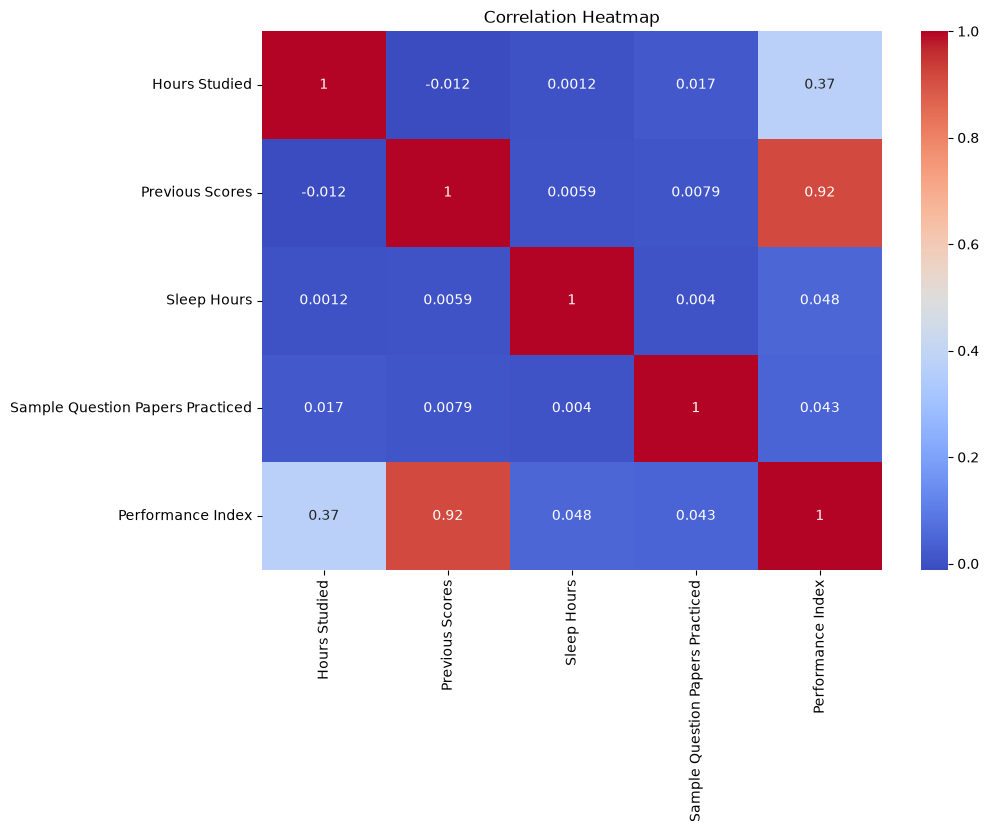

In [11]:
# Correlation Heatmap
plt.figure(figsize=(10,7)) 
sns.heatmap( df.corr(numeric_only=True), annot=True, cmap='coolwarm' ) 
plt.title("Correlation Heatmap") 
plt.show()

In [12]:
# Check Outliers
numeric_cols = [ 'Hours Studied', 'Previous Scores', 'Sleep Hours', 'Sample Question Papers Practiced', 'Performance Index' ] 
for col in numeric_cols: 
    Q1 = df[col].quantile(0.25) 
    Q3 = df[col].quantile(0.75) 
    IQR = Q3 - Q1 
    lower = Q1 - 1.5 * IQR 
    upper = Q3 + 1.5 * IQR 
    outliers = df[(df[col] < lower) | (df[col] > upper)] 
print(col, ":", len(outliers))

Performance Index : 0


In [21]:
df_encoded = pd.get_dummies(
    df,
    columns=['Extracurricular Activities'],
    drop_first=True,
    dtype=int
)

print(df_encoded.head())

   Hours Studied  Previous Scores  Sleep Hours  \
0              7               99            9   
1              4               82            4   
2              8               51            7   
3              5               52            5   
4              7               75            8   

   Sample Question Papers Practiced  Performance Index  \
0                                 1                 91   
1                                 2                 65   
2                                 2                 45   
3                                 2                 36   
4                                 5                 66   

   Extracurricular Activities_Yes  
0                               1  
1                               0  
2                               1  
3                               1  
4                               0  


In [22]:
# Define Independent and Dependent Variables
X = df_encoded.drop('Performance Index', axis=1) 
y = df_encoded['Performance Index']

In [23]:
# Split Dataset into Training and Testing Data
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42 ) 
print("Training data:", X_train.shape) 
print("Testing data:", X_test.shape)

Training data: (8000, 5)
Testing data: (2000, 5)


In [24]:
# Train Multiple Linear Regression Model
from sklearn.linear_model import LinearRegression


model = LinearRegression() 
model.fit(X_train, y_train) 
print("Intercept:", model.intercept_) 
print("Coefficients:", model.coef_)

Intercept: -33.92194621555611
Coefficients: [2.85248393 1.0169882  0.47694148 0.19183144 0.60861668]


In [25]:
# Prediction on Test Data
y_pred = model.predict(X_test) 
print(y_pred[:10])

[54.71185392 22.61551294 47.90314471 31.28976748 43.00457042 59.07125171
 45.90347516 86.45911791 37.70014037 72.05592481]


In [26]:
# Mean Absolute Error (MAE)
mae = mean_absolute_error(y_test, y_pred) 
print("MAE:", mae)

MAE: 1.6111213463123037


In [27]:
# Root Mean Squared Error (RMSE)
rmse = np.sqrt(mean_squared_error(y_test, y_pred)) 
print("RMSE:", rmse)

RMSE: 2.0205515085050054


In [28]:
# R2 Score
r2 = r2_score(y_test, y_pred) 
print("R2 Score:", r2)

R2 Score: 0.9889832909573145


In [29]:
# Adjusted R2
n = X_test.shape[0]  # number of observations
p = X_test.shape[1]  # number of predictors
adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R2 Score:", adjusted_r2)


Adjusted R2 Score: 0.9889556663107681
